# Stochastic Gradient Descent

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

## Step 0: Get Iris data

In [2]:
import pandas as pd
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
                 header=None, encoding='utf-8')

n_unique_categories = df[4].nunique()
unique_categories = df[4].unique()
print(f"There are {n_unique_categories} categories: {unique_categories}")

df.tail()

There are 3 categories: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Fitting a dataset with X: (100, 2) and y: (100,)


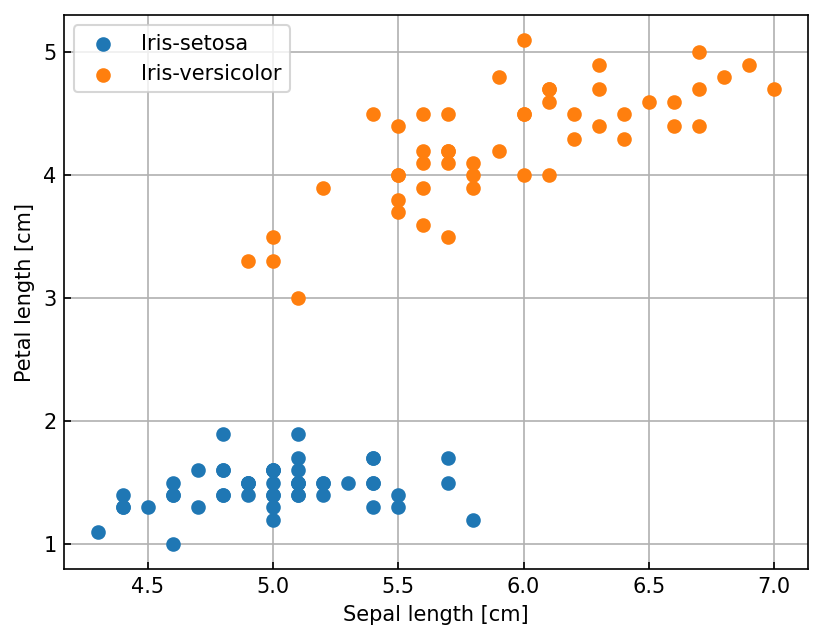

In [3]:
mask = df[4] != 'Iris-virginica'

X = df.loc[mask, [0, 2]].values
y = df.loc[mask, 4].values
print(f"Fitting a dataset with X: {X.shape} and y: {y.shape}")

labels = np.unique(y)
ax = plt.figure().gca()
for label in labels:
    mask = y == label
    ax.scatter(X[mask, 0], X[mask, 1], label=label)
ax.set(xlabel='Sepal length [cm]', ylabel='Petal length [cm]')
ax.legend();

In [4]:
y_enc = np.zeros(y.shape)
y_enc[y == 'Iris-versicolor'] = 1
print(f'There are {int(y_enc.sum())} examples of Iris-versicolor')

There are 50 examples of Iris-versicolor


## Step 1: Define base Adaline class with Gradient Descent

In [5]:
import numpy as np

class AdalineGD:
    """ Full-batch gradient descent variant
        
        Parameters:
        -----------
        alpha : float - Learning rate
        num_epochs : int - Iterations over the training data
        random_seed : int - Random seed

        Attributes:
        -----------
        w_ : 1d array of weights
        b_ : bias term
    """
    def __init__(self,
                 alpha=0.01, 
                 num_epochs=100,
                 random_seed=42):
        self.alpha = alpha
        self.num_epochs = num_epochs
        self.random_seed = random_seed

    def fit(self, X, y):
        """ X : ndarray with shape [n_examples, n_features]
            y : ndarray with shape [n_examples,]
        """
        np.random.seed(self.random_seed)
        self.w_ = np.random.normal(loc=0, scale=0.01, size=X.shape[1])
        self.b_ = np.float32(0.)

        self.loss = []
        self.w_history = []
        self.b_history = []
        
        # iterate over epochs
        for _ in range(self.num_epochs):
             loss = self._fit_epoch(X, y)
             self.loss.append(loss)

        return self

    def _fit_epoch(self, X, y):
        """ Helper function to make variants (SGD, Minibatch) 
            simpler to implement, and maximize code reuse
        """
        diff = y - self.pre_activation(X)

        self.w_history.append(self.w_.copy())
        self.b_history.append(self.b_)
        
        self.w_ += 2. * self.alpha * diff.dot(X) / X.shape[0]
        self.b_ += 2. * self.alpha * diff.mean()

        loss = np.power(diff, 2).mean()
        return loss

    def pre_activation(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        z = self.pre_activation(X)
        return np.where(z >= 0.5, 1, 0)

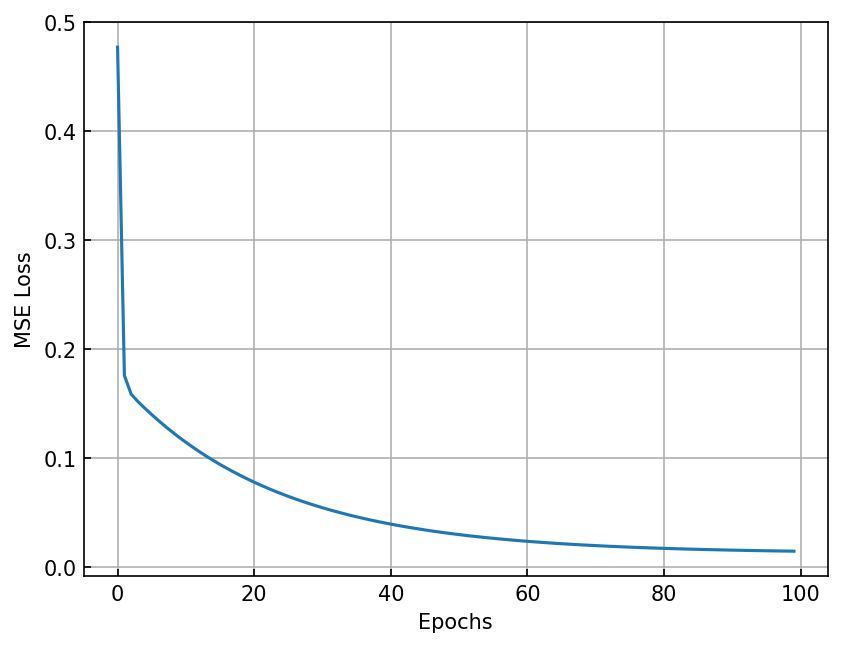

In [6]:
gd_model = AdalineGD()
gd_model.fit(X, y_enc)

ax = plt.figure().gca()
ax.plot(gd_model.loss)
ax.set(xlabel='Epochs', ylabel='MSE Loss', yscale='linear');

## Adaline with SGD

In [7]:
def shuffle(X, y):
    """ Shuffle training data each epoch """
    idx = np.random.permutation(X.shape[0])
    return X[idx, :], y[idx]

class AdalineSGD(AdalineGD):
    """ Subclass only differs in when the gradient updates occur
    """
    def _fit_epoch(self, X, y):
        X_shuf, y_shuf = shuffle(X, y)

        loss = 0.

        for xi, yi in zip(X_shuf, y_shuf):
            diff = yi - self.pre_activation(xi)

            self.w_history.append(self.w_.copy())
            self.b_history.append(self.b_)
            
            self.w_ += 2. * self.alpha * xi * diff
            self.b_ += 2. * self.alpha * diff

            loss += diff**2

        return loss / X.shape[0]

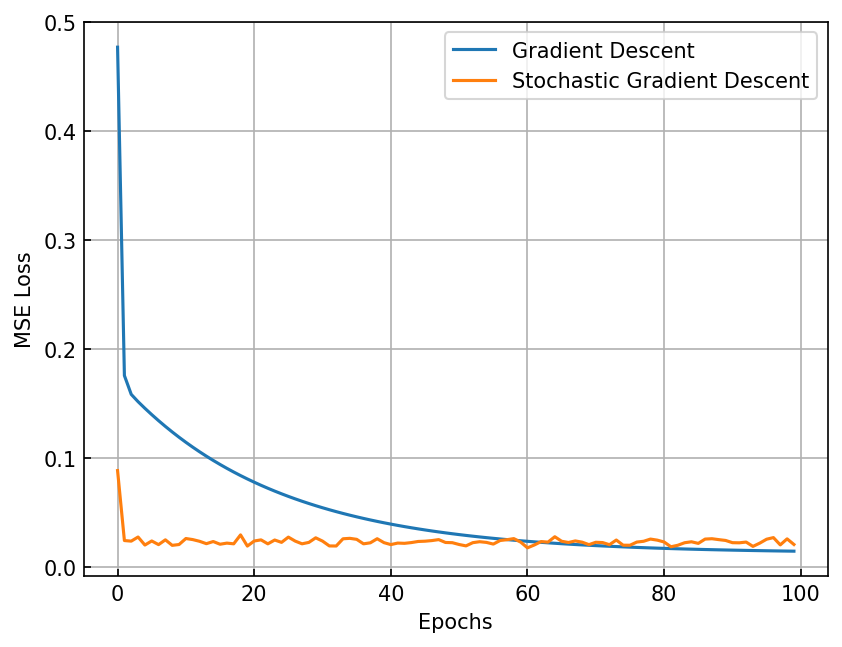

In [8]:
sgd_model = AdalineSGD()
sgd_model.fit(X, y_enc)

ax = plt.figure().gca()
ax.plot(gd_model.loss, label='Gradient Descent')
ax.plot(sgd_model.loss, label='Stochastic Gradient Descent')
ax.legend()
ax.set(xlabel='Epochs', ylabel='MSE Loss', yscale='linear');

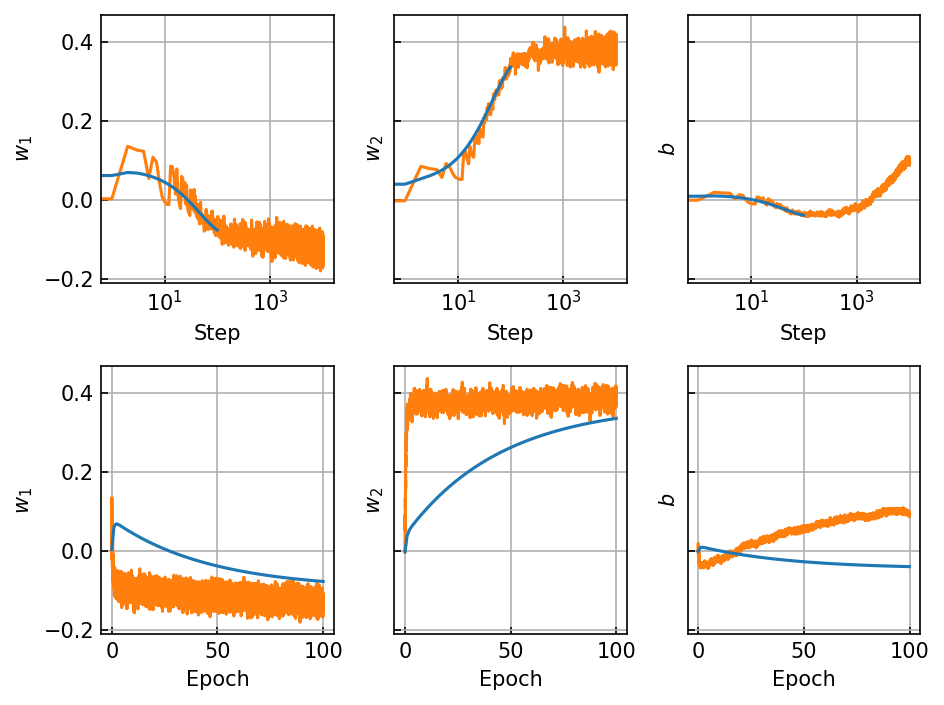

In [9]:
def plot_weight_trajectory_steps(axes, model, color='black', labels=['$w_1$', '$w_2$', '$b$']):
    w = np.stack(model.w_history)
    b = np.array(model.b_history)
    wb = np.concatenate([w, b[:, None]], axis=1)
    tt = np.arange(w.shape[0])

    for ii in range(axes.shape[0]):
        axes[ii].plot(tt, wb[:, ii], color=color, label=model.__class__.__name__)
        axes[ii].set_ylabel(labels[ii])
        axes[ii].set_xlabel('Step')
        axes[ii].set_xscale('log')

def plot_weight_trajectory_epochs(axes, model, color='black', labels=['$w_1$', '$w_2$', '$b$']):
    w = np.stack(model.w_history)
    b = np.array(model.b_history)
    wb = np.concatenate([w, b[:, None]], axis=1)
    tt = np.linspace(0, len(model.loss), wb.shape[0])

    for ii in range(axes.shape[0]):
        axes[ii].plot(tt, wb[:, ii], color=color, label=model.__class__.__name__)
        axes[ii].set_ylabel(labels[ii])
        axes[ii].set_xlabel('Epoch')
        axes[ii].set_xscale('linear')

fig, axes = plt.subplots(2, 3, sharex='row', sharey=True)

plot_weight_trajectory_steps(axes[0], sgd_model, color='tab:orange')
plot_weight_trajectory_epochs(axes[1], sgd_model, color='tab:orange')

plot_weight_trajectory_steps(axes[0], gd_model, color='tab:blue')
plot_weight_trajectory_epochs(axes[1], gd_model, color='tab:blue')

plt.tight_layout()

## Minibatch SGD Adaline definition

In [10]:
class AdalineMiniBatchSGD(AdalineGD):
    def __init__(self, batch_size=16, **kwargs):
        """ batch_size - the size of the sample to draw each iteration
        """
        self.batch_size=batch_size
        super().__init__(**kwargs)

    def _fit_epoch(self, X, y):
        X_shuf, y_shuf = shuffle(X, y)

        loss = 0.

        for batch_start in range(0, X.shape[0], self.batch_size):
            batch_end = batch_start + self.batch_size
            xb = X_shuf[batch_start:batch_end, :]
            yb = y_shuf[batch_start:batch_end]

            diff = yb - self.pre_activation(xb)

            self.w_history.append(self.w_.copy())
            self.b_history.append(self.b_)
            self.w_ += 2. * self.alpha * diff.dot(xb) / xb.shape[0]
            self.b_ += 2. * self.alpha * diff.mean()

            loss += np.sum(diff**2)

        return loss / X.shape[0]

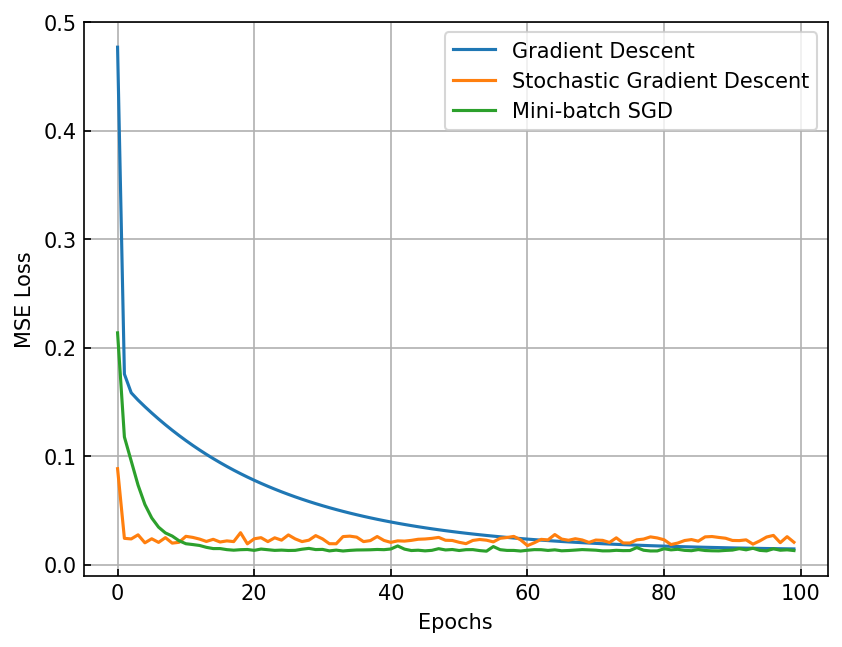

In [11]:
mb_model = AdalineMiniBatchSGD()
mb_model.fit(X, y_enc)

ax = plt.figure().gca()
ax.plot(gd_model.loss, label='Gradient Descent')
ax.plot(sgd_model.loss, label='Stochastic Gradient Descent')
ax.plot(mb_model.loss, label='Mini-batch SGD')
ax.legend()
ax.set(xlabel='Epochs', ylabel='MSE Loss', yscale='linear');

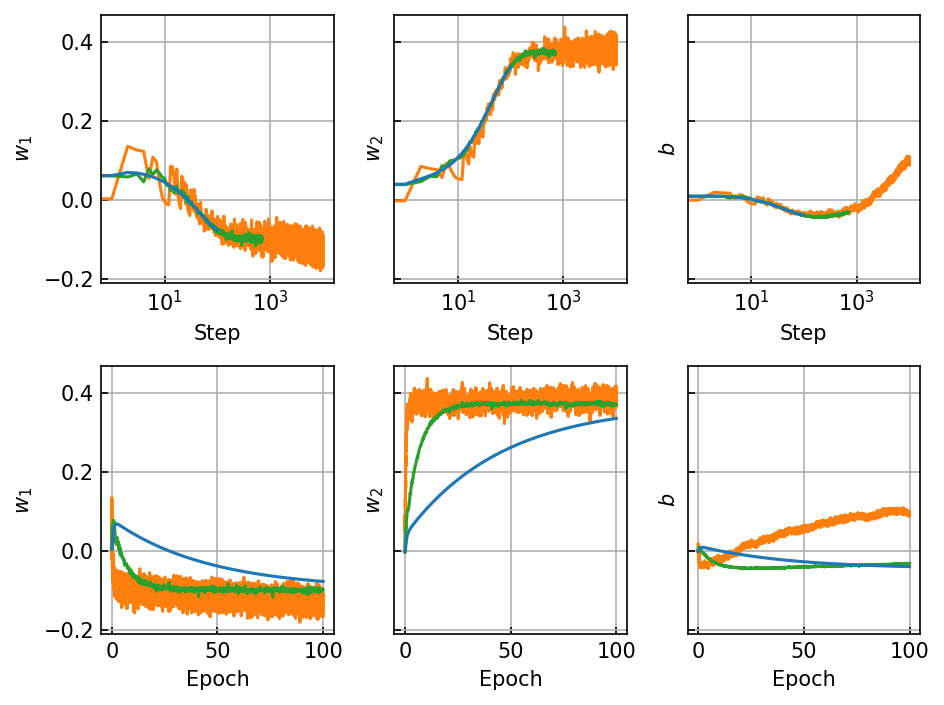

In [12]:
fig, axes = plt.subplots(2, 3, sharex='row', sharey=True)

plot_weight_trajectory_steps(axes[0], sgd_model, color='tab:orange')
plot_weight_trajectory_epochs(axes[1], sgd_model, color='tab:orange')

plot_weight_trajectory_steps(axes[0], mb_model, color='tab:green')
plot_weight_trajectory_epochs(axes[1], mb_model, color='tab:green')

plot_weight_trajectory_steps(axes[0], gd_model, color='tab:blue')
plot_weight_trajectory_epochs(axes[1], gd_model, color='tab:blue')

plt.tight_layout()

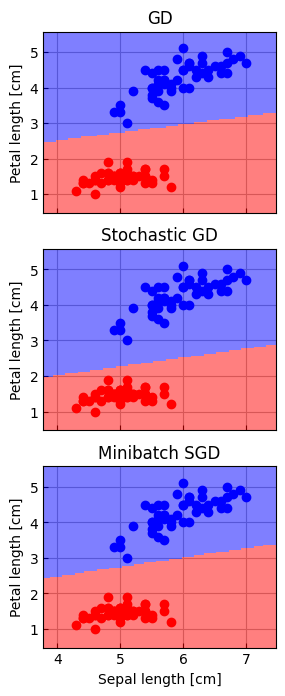

In [13]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(ax, X, y, model, d=0.05, colors=['red', 'blue']):
    x1, x2 = np.meshgrid(
        np.arange(X[:, 0].min() - 10*d, X[:, 0].max() + 10*d, d),
        np.arange(X[:, 1].min() - 10*d, X[:, 1].max() + 10*d, d),
    )
    y_grid = model.predict(np.stack([x1.ravel(), x2.ravel()]).T) # [N, 2]
    y_grid = y_grid.reshape(x1.shape)

    cmap = ListedColormap(colors)
    im = ax.pcolormesh(x1, x2, y_grid, cmap=cmap, alpha=0.5)

    for ii, label in enumerate(np.unique(y)):
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], color=colors[int(label)])
        

fig, ax = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(3, 8), dpi=100)
plot_decision_boundary(ax[0], X, y_enc, gd_model)
plot_decision_boundary(ax[1], X, y_enc, sgd_model)
plot_decision_boundary(ax[2], X, y_enc, mb_model)

ax[0].set(title='GD', ylabel='Petal length [cm]')
ax[1].set(title='Stochastic GD', ylabel='Petal length [cm]')
ax[2].set(title='Minibatch SGD', xlabel='Sepal length [cm]', ylabel='Petal length [cm]');